<p align="center">
  <img src="../assets/prodinno_logo.png" alt="Prodinno" width="200">
</p>

<h4 align="center">Session 2 &middot; XGBoost & Random Forest</h4>
<h1 align="center">XGBoost &mdash; Pima Indians Diabetes</h1>
<p align="center"><i>Finding and fixing disguised missing values before any model sees them</i></p>

---

## Why this notebook exists

Before we let a boosting algorithm anywhere near this data, we need to look at it the way a
clinician or a careful analyst would. The Pima Indians Diabetes dataset is a widely used
benchmark for binary classification, but it carries a well-known and easy-to-miss defect:
**several biologically impossible zeros are standing in for missing measurements.**

We are not going to manufacture a problem to teach a lesson. This dataset **already ships**
with the problem, the same way real hospital, insurance, and sensor data ships with silent
recording gaps. Our job in this notebook is entirely diagnostic and corrective:

1. **Detect** where zero cannot possibly be a true reading (nobody has 0 BMI or 0 blood
   pressure and is still alive to be measured).
2. **Quantify** exactly how much of the data is affected, column by column.
3. **Fix** it with a principled imputation strategy, and **prove** the fix didn't distort the
   relationship between each feature and the outcome we ultimately want to predict.

> **Key idea:** a "clean-looking" CSV with no `NaN` values is not the same thing as a clean
> dataset. `pandas.read_csv` will happily load `0` as a perfectly valid integer -- it has no
> way of knowing that a `0` in the `Insulin` column is nonsense. That judgment call belongs to
> us.

## 1. Load the raw data

In [1]:
import numpy as np
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (10, 5)

RAW_PATH = "data/diabetes_raw.csv"
df_raw = pd.read_csv(RAW_PATH)
df_raw.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


### `.describe()` -- the first diagnostic tool

Look closely at the **`min`** row below. For a handful of columns, the minimum observed value
is `0`. That is medically meaningless for these particular measurements:

- **`Glucose`** -- plasma glucose concentration. A living person cannot have 0 mg/dL glucose.
- **`BloodPressure`** -- diastolic blood pressure. 0 mmHg means no measurement was taken.
- **`SkinThickness`** -- triceps skinfold thickness. 0 mm is not a valid caliper reading.
- **`Insulin`** -- 2-hour serum insulin. 0 mu U/mL essentially never occurs.
- **`BMI`** -- body mass index. 0 is not a survivable BMI.

Contrast these with `Pregnancies` (0 is a completely valid count) and `Age` /
`DiabetesPedigreeFunction`, where the observed minimums are plausible. **The presence of a
zero is not automatically a problem -- it is a problem only when domain knowledge tells you
that value cannot occur.** This is why detection needs a human with context, not just a
generic "are there zeros" check.

In [3]:
df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


## 2. Quantify the damage

Domain knowledge tells us *which* columns are suspect. Now we count exactly how many rows are
affected in each one, and convert those sentinel zeros to proper `NaN` so every downstream
tool (`.isna()`, `missingno`, `.describe()`, imputers) recognizes them as missing rather than
as valid readings of zero.

In [4]:
SENTINEL_ZERO_COLS = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

zero_counts = (df_raw[SENTINEL_ZERO_COLS] == 0).sum().sort_values(ascending=False)
zero_pct = (zero_counts / len(df_raw) * 100).round(1)

summary = pd.DataFrame({"zero_count": zero_counts, "pct_of_rows": zero_pct})
summary

,zero_count,pct_of_rows
Insulin,374,48.7
SkinThickness,227,29.6
BloodPressure,35,4.6
BMI,11,1.4
Glucose,5,0.7


### The headline number

`Insulin` alone has **374 zeros out of 768 rows -- 48.7% of the entire column**. Nearly one in
every two patients has no recorded insulin reading. This single statistic is the whole reason
this notebook exists: if we simply *dropped every row with a missing value*, we would throw
away roughly half the dataset before a single tree is trained, and we would almost certainly
bias the remaining sample (rows with insulin recorded are not a random subsample -- they may
correlate with which clinic visit, era, or protocol collected them).

> **Blockquote callout:** dropping rows is not a neutral default. It is a decision with a
> cost, and here that cost is catastrophic. We reject it explicitly below.

In [5]:
df_nan = df_raw.copy()
df_nan[SENTINEL_ZERO_COLS] = df_nan[SENTINEL_ZERO_COLS].replace(0, np.nan)

print("Missing values per column after converting sentinel zeros to NaN:")
df_nan.isna().sum()

Missing values per column after converting sentinel zeros to NaN:


Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

### Visualizing the missingness pattern

`missingno` gives us two complementary views, computed **after** the 0 -> `NaN` conversion
(before the conversion, `missingno` would report zero missing values everywhere, because it
only understands actual `NaN`, not disguised sentinels):

- **Matrix plot** -- one row per patient, one column per feature; white streaks show where
  data is missing. This lets us see whether missingness clusters in certain rows (it does not
  appear to here -- it looks fairly scattered) or across columns (it clearly does: `Insulin`
  and `SkinThickness` are missing far more often than `Glucose` or `BloodPressure`).
- **Bar plot** -- a simple per-column completeness count, which makes the `Insulin` and
  `SkinThickness` gaps immediately obvious at a glance.

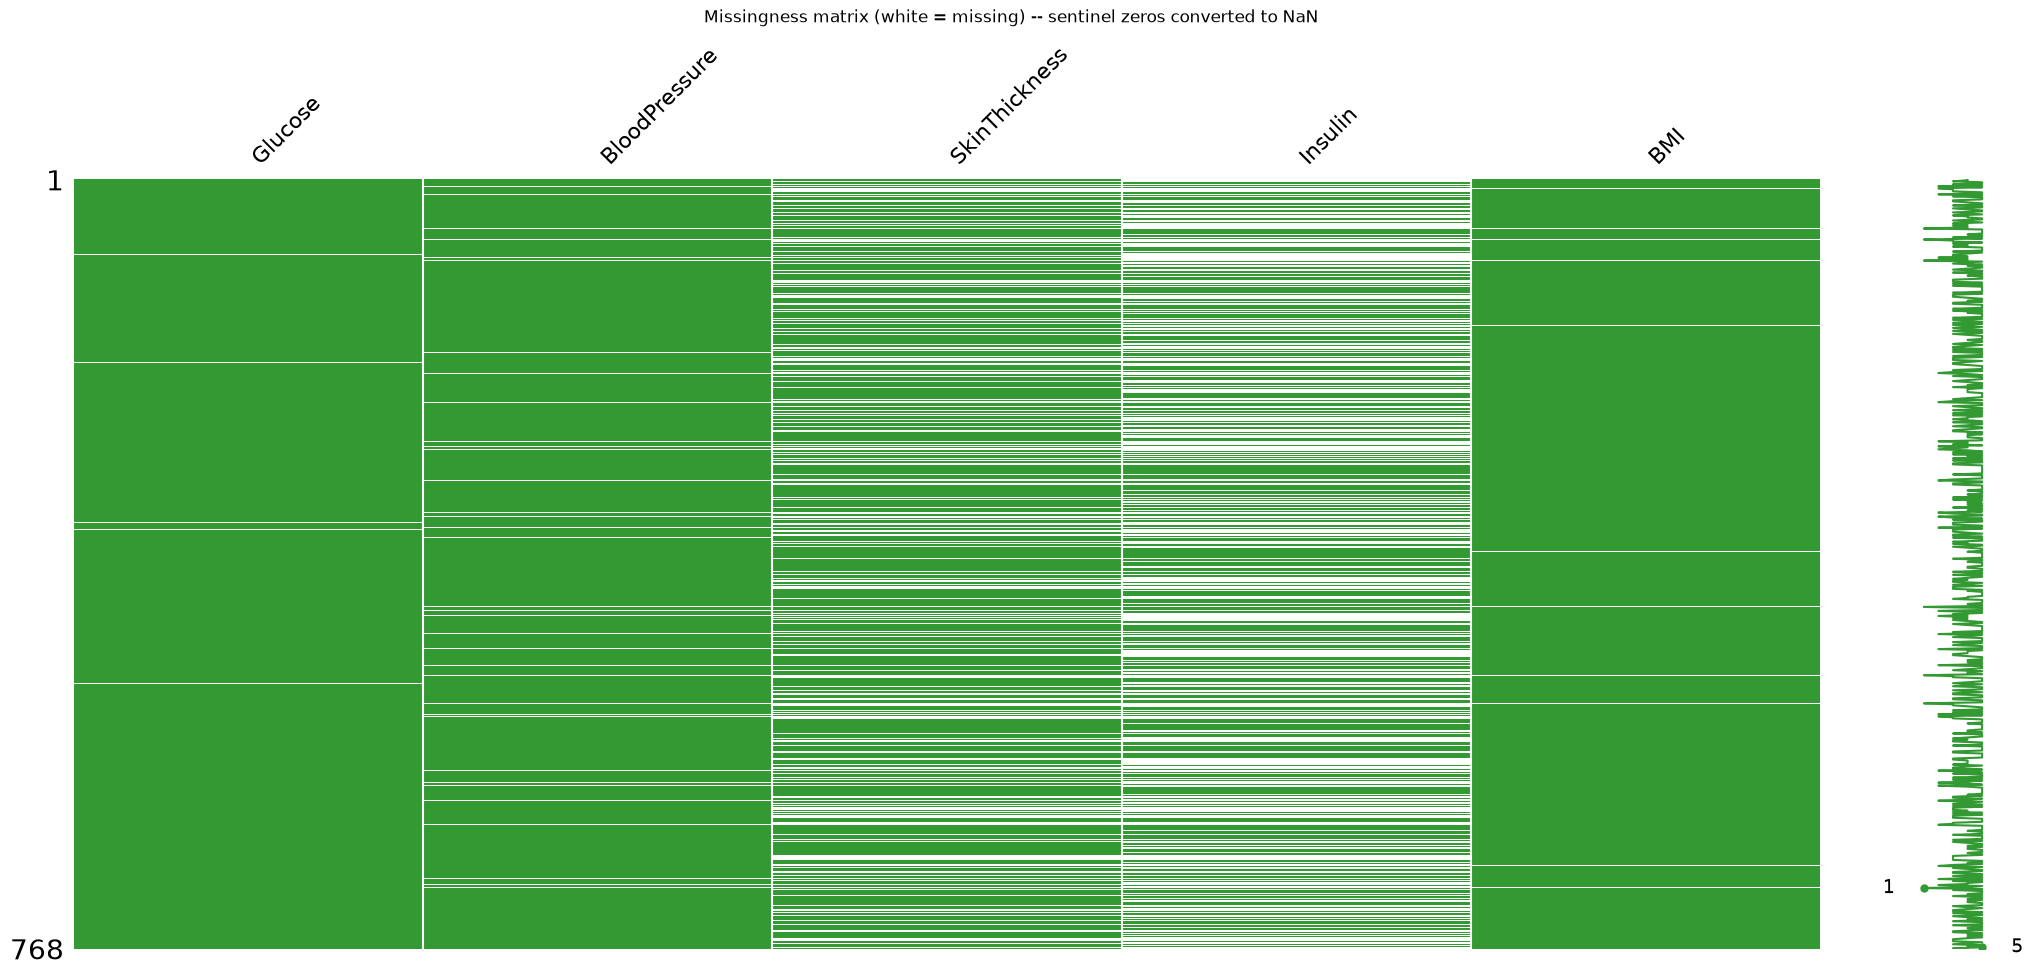

: 

In [ ]:
msno.matrix(df_nan[SENTINEL_ZERO_COLS],  color=(0.2,0.6,0.2))
plt.suptitle("Missingness matrix (white = missing) - sentinel zeros converted to NaN", y=1.05)
plt.show()

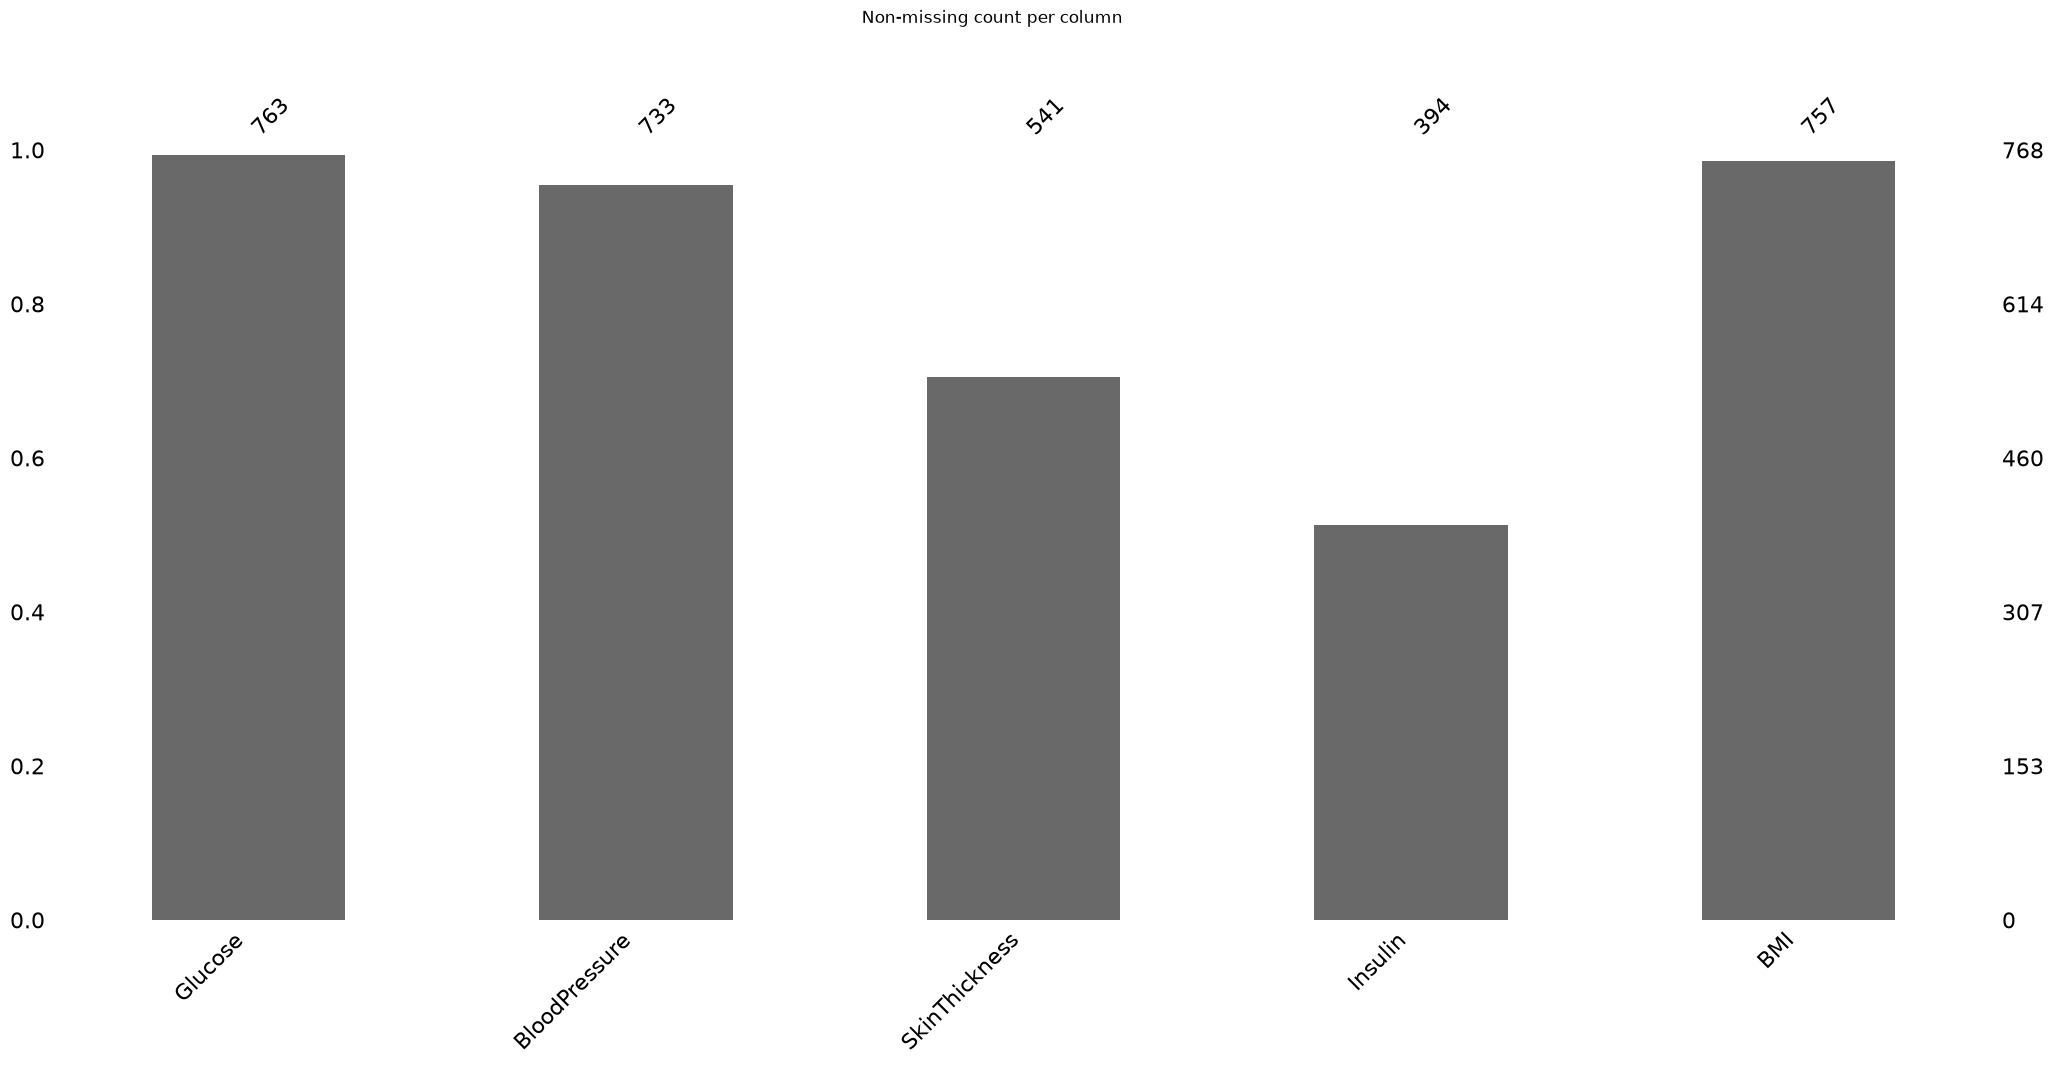

In [7]:
msno.bar(df_nan[SENTINEL_ZERO_COLS])
plt.suptitle("Non-missing count per column", y=1.02)
plt.show()

## 3. The fix: outcome-grouped median imputation

We have two broad choices once a column has missing values:

1. **Drop the affected rows.** Rejected: `Insulin` alone would cost us ~49% of the dataset,
   and the loss compounds once you consider rows with *multiple* sentinel zeros overlapping.
   This is not a viable option here.
2. **Impute a value.** We choose imputation, and we choose it carefully:
   - **Median, not mean.** These clinical measurements are right-skewed (a small number of
     very high glucose or insulin readings pull the mean upward). The median is robust to
     that skew and gives a more representative "typical" value.
   - **Grouped by `Outcome`, not global.** Diabetic and non-diabetic patients genuinely differ
     in typical glucose and BMI. A single global median would wash out that class-conditional
     signal -- exactly the signal the model needs to learn from. Imputing the diabetic group's
     missing glucose values with the diabetic group's own median (and likewise for the
     non-diabetic group) **preserves** the relationship between the feature and the target
     instead of diluting it toward the overall average.

Formally, for a column $x$ with sentinel zeros converted to `NaN`, and outcome class
$c \in \{0, 1\}$:

$$\hat{x}_i = \begin{cases} x_i & \text{if } x_i \text{ observed} \\ \operatorname{median}(x_j : y_j = c) & \text{if } x_i \text{ missing and } y_i = c \end{cases}$$

In [8]:
df_clean = df_nan.copy()

group_medians = df_clean.groupby("Outcome")[SENTINEL_ZERO_COLS].median()
print("Median value per column, computed separately within each Outcome class:")
group_medians

Median value per column, computed separately within each Outcome class:


,Glucose,BloodPressure,SkinThickness,Insulin,BMI
Outcome,,,,,
0,107.0,70.0,27.0,102.5,30.1
1,140.0,74.5,32.0,169.5,34.3


In [9]:
for col in SENTINEL_ZERO_COLS:
    df_clean[col] = df_clean.groupby("Outcome")[col].transform(lambda s: s.fillna(s.median()))

print("Remaining missing values after outcome-grouped median imputation:")
df_clean.isna().sum()

Remaining missing values after outcome-grouped median imputation:


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## 4. Before / after: did the fix actually work?

A responsible imputation step does not just "make the NaNs go away" -- it should leave the
statistical relationships in the data intact. We check this two ways:

1. **Distributions.** The tell-tale sign of an *unfixed* sentinel-zero problem is a spike at 0
   sitting apart from the rest of an otherwise smooth distribution. After imputation, that
   spike should be gone, replaced by mass around the (class-conditional) median.
2. **Correlation with `Outcome`.** If our grouped-median approach preserved the
   class-conditional signal, the correlation between each imputed feature and `Outcome`
   should stay roughly the same sign and magnitude as it was among only the *originally
   observed* (non-zero) values -- not flip sign, and not collapse toward zero.

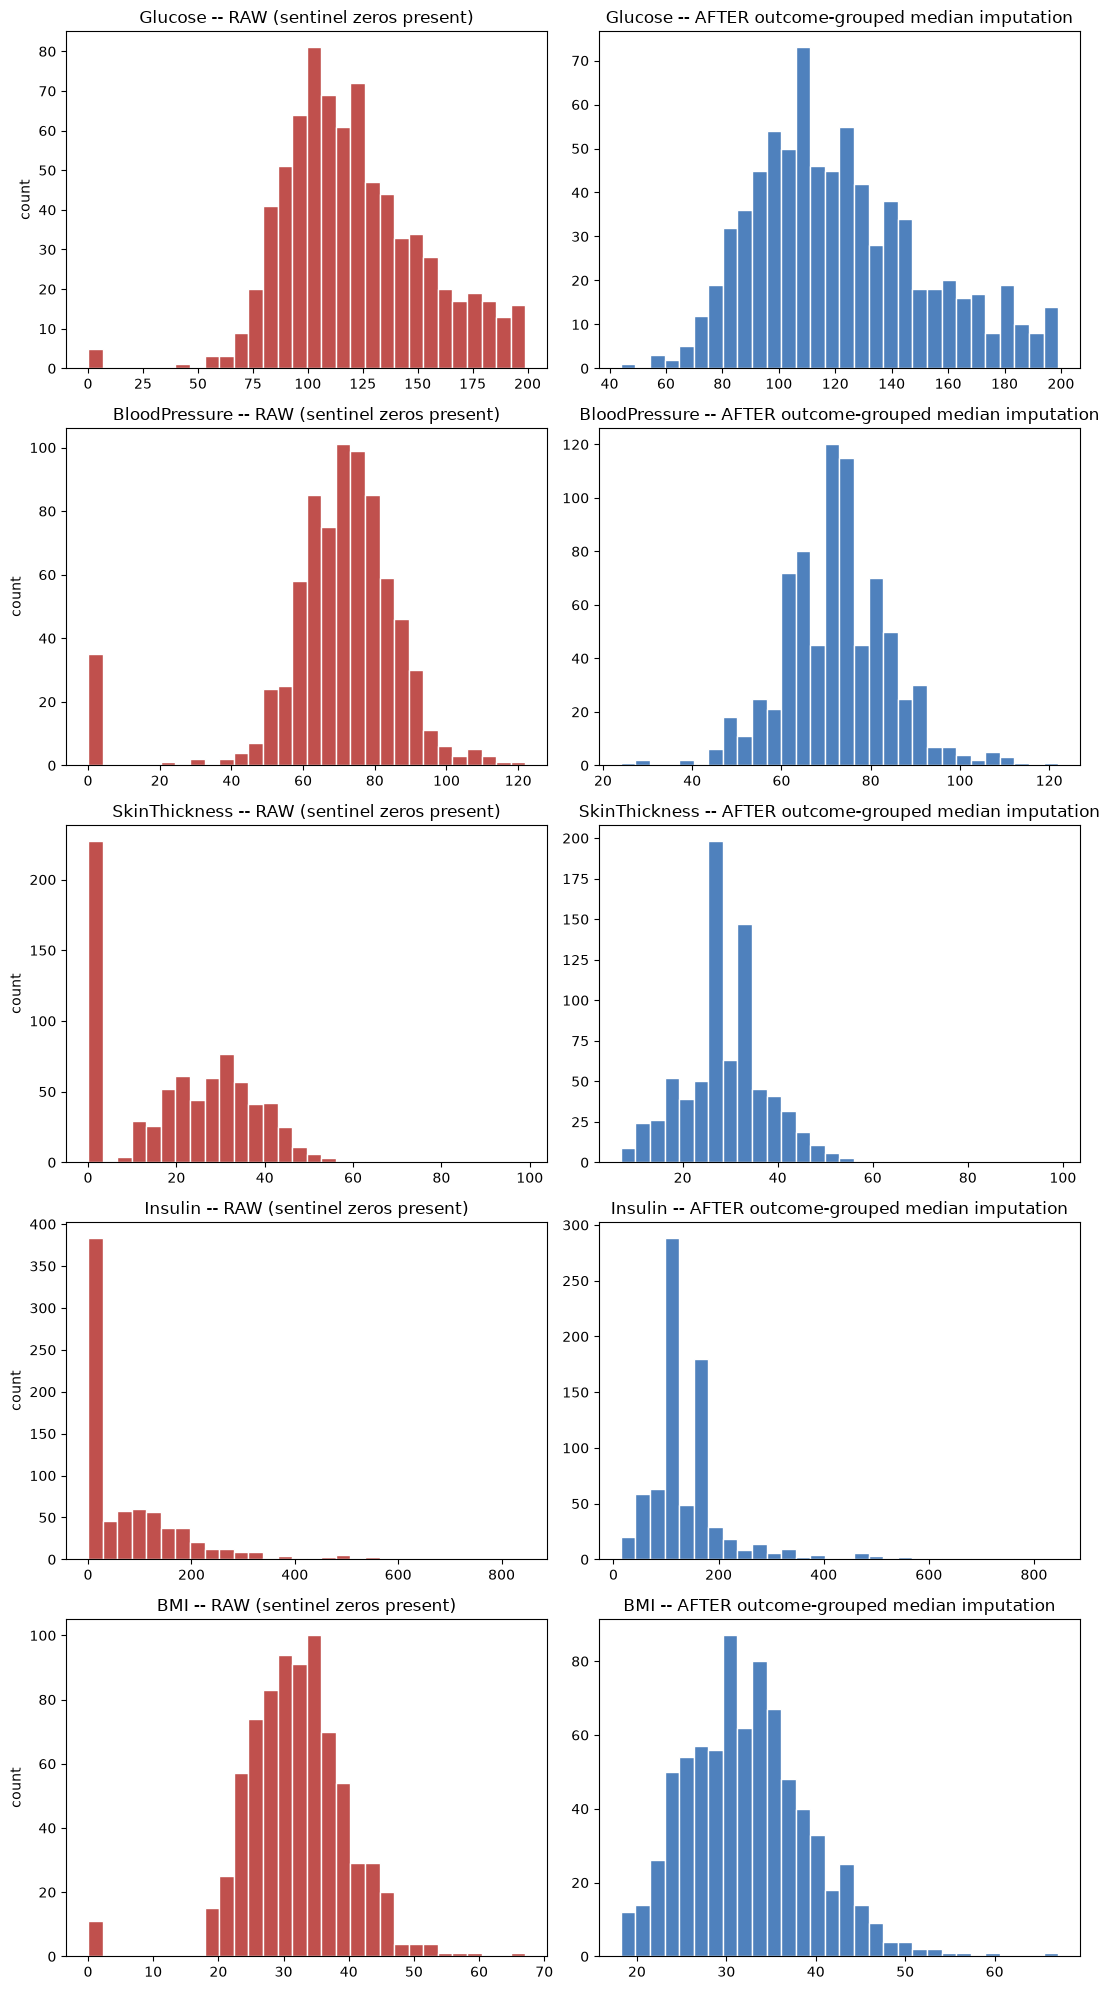

In [ ]:
fig, axes = plt.subplots(len(SENTINEL_ZERO_COLS), 2, figsize=(11, 4 * len(SENTINEL_ZERO_COLS)))

for i, col in enumerate(SENTINEL_ZERO_COLS):
    axes[i, 0].hist(df_raw[col], bins=30, color="#c0504d", edgecolor="white")
    axes[i, 0].set_title(f"{col} - RAW (sentinel zeros present)")
    axes[i, 0].set_ylabel("count")

    axes[i, 1].hist(df_clean[col], bins=30, color="#4f81bd", edgecolor="white")
    axes[i, 1].set_title(f"{col} - AFTER outcome-grouped median imputation")

plt.tight_layout()
plt.show()

Notice the zero-spike on the left column disappearing on the right for every affected
feature -- most dramatically for `Insulin` and `SkinThickness`, the two columns with the most
missingness. The rest of each distribution's shape is otherwise undisturbed.

In [11]:
rows = []
for col in SENTINEL_ZERO_COLS:
    observed_mask = df_raw[col] != 0
    corr_before = df_raw.loc[observed_mask, col].corr(df_raw.loc[observed_mask, "Outcome"])
    corr_after = df_clean[col].corr(df_clean["Outcome"])
    rows.append({
        "feature": col,
        "corr_with_outcome_before (observed rows only)": round(corr_before, 3),
        "corr_with_outcome_after (imputed)": round(corr_after, 3),
        "sign_flipped": (corr_before > 0) != (corr_after > 0),
    })

corr_check = pd.DataFrame(rows)
corr_check

,feature,corr_with_outcome_before (observed rows only),corr_with_outcome_after (imputed),sign_flipped
0,Glucose,0.495,0.496,False
1,BloodPressure,0.171,0.174,False
2,SkinThickness,0.259,0.295,False
3,Insulin,0.303,0.377,False
4,BMI,0.314,0.316,False


No feature flips sign, and none of the correlations collapse toward zero -- if anything
several strengthen slightly, because we removed the noise of a nonsensical "0" being treated
as a real low reading. This is our sanity check passing: the imputation fixed the missingness
problem without erasing the signal we ultimately want the model to learn.

> **Callout:** this "did the fix preserve the signal" check is a habit worth keeping for any
> imputation strategy, not just this one. An imputation that "removes the NaNs" but destroys
> the feature-target relationship is worse than no imputation at all.

## 5. Save the cleaned dataset

This cleaned, fully-imputed dataset is the input to the next notebook, `01_eda.ipynb`, where
we explore it visually before building any model.

In [ ]:
OUT_PATH = "data/diabetes_clean.csv"
df_clean.to_csv(OUT_PATH, index=False)
print(f"Saved cleaned dataset to {OUT_PATH} - shape {df_clean.shape}")

Saved cleaned dataset to data/diabetes_clean.csv -- shape (768, 9)


## Summary

- Five columns (`Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`) used `0` as a
  disguised stand-in for "not recorded."
- `Insulin` was the worst offender at **374/768 rows (48.7%)** missing -- dropping those rows
  was never a realistic option.
- We converted sentinel zeros to `NaN`, visualized the pattern with `missingno`, and imputed
  using the **median within each `Outcome` class**, which resists skew and preserves the
  class-conditional signal.
- We verified the fix with before/after distribution plots and a correlation sanity check --
  no sign flips, no signal collapse.
- The result is saved as `data/diabetes_clean.csv` for use in every subsequent notebook.